<a href="https://colab.research.google.com/github/YoungJang-KR/semiconductor-fault-detection/blob/main/01_EDA_PHM18_etching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 구글 드라이브-코랩 연동
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# pandas를 가지고 train 폴더의 01_M01_DC_train.csv 파일 분석하기
import pandas as pd

path_train = '/content/drive/MyDrive/phm18/train/01_M01_DC_train.csv'

df_train = pd.read_csv(path_train)
print("행, 렬:", df_train.shape)
print("열 항목:", df_train.columns.tolist())

행, 렬: (3124704, 24)
열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION']


In [3]:
# 마찬가지로 train_ttf 폴더의 01_M01_DC_train.csv 파일 분석하기
path_ttf = '/content/drive/MyDrive/phm18/train_ttf/01_M01_DC_train.csv'

df_ttf = pd.read_csv(path_ttf)
print("행, 렬:", df_ttf.shape)
print("열 항목:", df_ttf.columns.tolist())

행, 렬: (3124704, 4)
열 항목: ['time', 'TTF_FlowCool Pressure Dropped Below Limit', 'TTF_Flowcool Pressure Too High Check Flowcool Pump', 'TTF_Flowcool leak']


In [4]:
# train_ttf 파일의 열 항목 이름이 너무 긺으로 수정하기
df_ttf = df_ttf.rename( columns={
    'TTF_FlowCool Pressure Dropped Below Limit': 'TTF_pressure_drop',
    'TTF_Flowcool Pressure Too High Check Flowcool Pump': 'TTF_pressure_high',
    'TTF_Flowcool leak': 'TTF_leak'
})

# 변경이 잘 되었나 확인
print("열 항목:", df_ttf.columns.tolist())

열 항목: ['time', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


In [5]:
# 분석을 위해서 train 파일과 train_ttf 파일을 시간에 대해 merge
df = df_train.merge( df_ttf, on='time' )

# merge가 잘 되었나 확인, 열의 개수는 27이 되어야 함
print("행, 렬:", df.shape)

행, 렬: (3135742, 27)


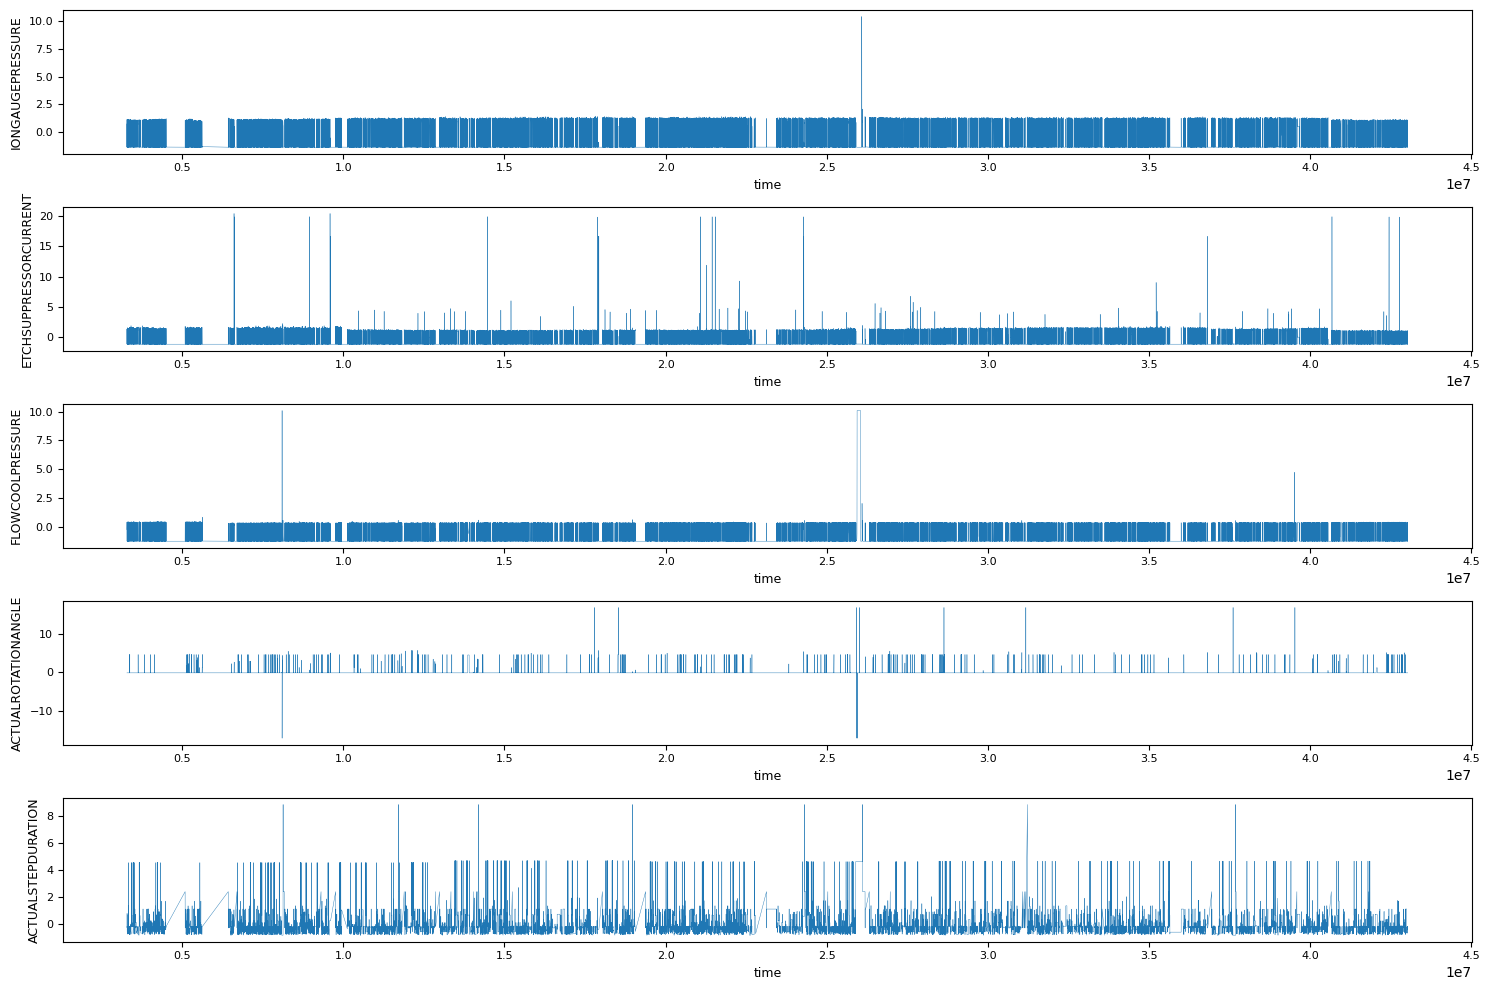

In [6]:
# 센서값(측정값)들을 시간에 대해 시각화 해보기

sensor_cols = [ 'IONGAUGEPRESSURE',     # 챔버 내부 압력
               'ETCHSUPPRESSORCURRENT', # 억제 그리드 전류 - 이상적으로는 0이어야 함
                'FLOWCOOLPRESSURE',     # 기체 헬륨이 든 냉각관의 압력
                'ACTUALROTATIONANGLE',  # 웨이퍼가 실제 회전한 각도
                'ACTUALSTEPDURATION'    # 특정 공정이 실제로 진행된 시간
                ]

import matplotlib.pyplot as plt

fig, axes = plt.subplots( len(sensor_cols), 1, figsize=(15, len(sensor_cols)*2) )

for i, col in enumerate(sensor_cols):
  axes[i].plot( df['time'], df[col], linewidth=0.3 )
  axes[i].set_xlabel('time',fontsize=9)
  axes[i].set_ylabel(col, fontsize=9)
  axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

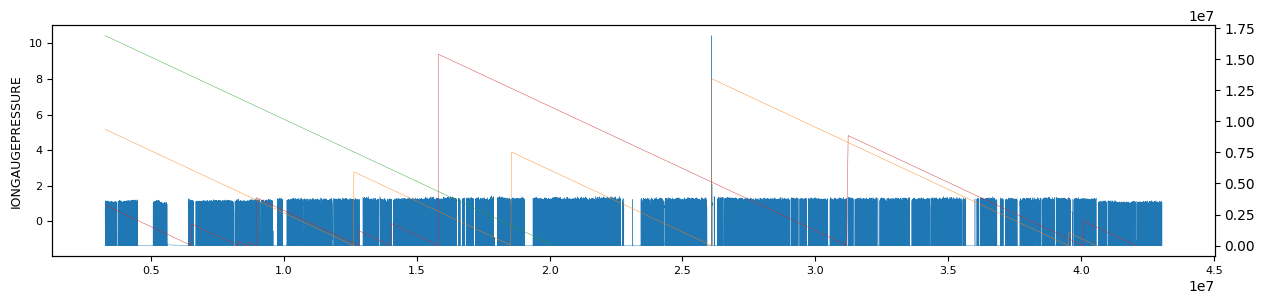

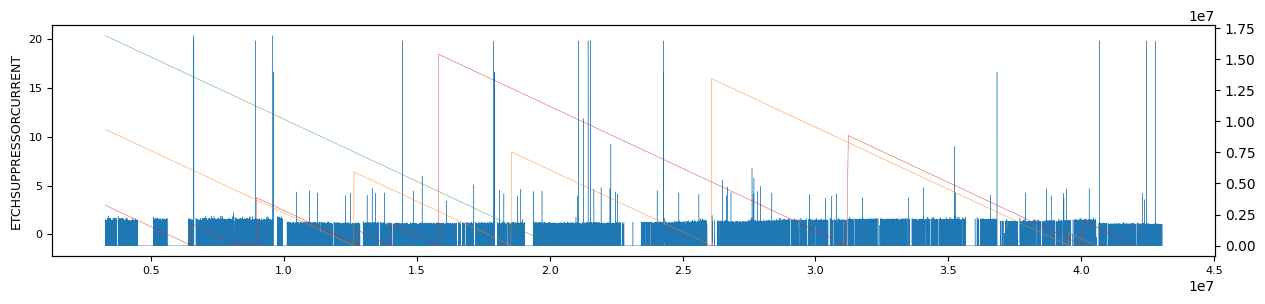

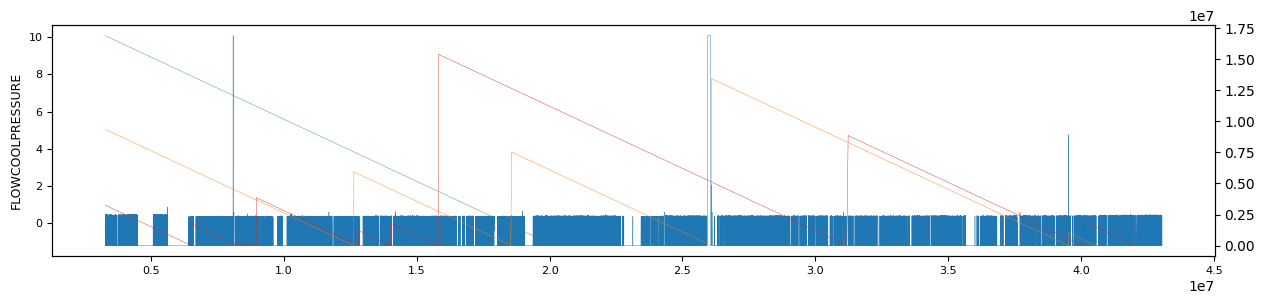

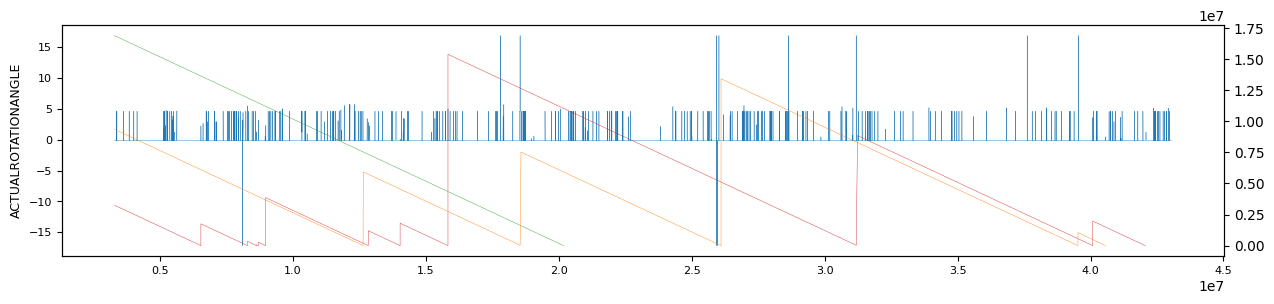

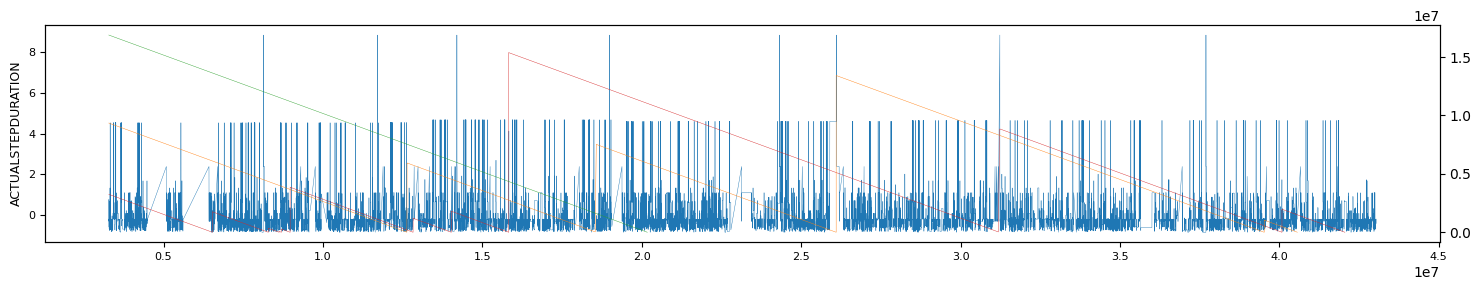

In [7]:
# 고장(TTF) 변수들 역시 시간에 대해 시각화 해보자

for col in sensor_cols:
  fig, ax1 = plt.subplots(figsize=(15, 3))
  ax1.plot( df['time'], df[col], linewidth=0.3, color='tab:blue' )
  ax1.set_ylabel(col, fontsize=9)
  ax1.tick_params(labelsize=8)

  ax2 = ax1.twinx()
  ax2.plot( df['time'], df['TTF_pressure_drop'], linewidth=0.3, color='tab:red' )
  ax2.plot( df['time'], df['TTF_pressure_high'], linewidth=0.3, color='tab:orange')
  ax2.plot( df['time'], df['TTF_leak'], linewidth=0.3, color='tab:green')

plt.tight_layout()
plt.show()


In [8]:
# 이대로는 무언가를 알기 힘듦으로 상관관계 분석해보기

ttf_cols = [ 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak' ]
train_cols = [ 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT',
             'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE',
              'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK',
              'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION',
              'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION' ]

corr = df[ train_cols + ttf_cols ].corr() # ()
corr_ttf = corr.loc[ train_cols, ttf_cols ]
print( corr_ttf )

                         TTF_pressure_drop  TTF_pressure_high  TTF_leak
IONGAUGEPRESSURE                  0.010567           0.008017 -0.001035
ETCHBEAMVOLTAGE                   0.013649           0.011060 -0.003264
ETCHBEAMCURRENT                   0.006055           0.007851  0.016645
ETCHSUPPRESSORVOLTAGE            -0.003918           0.013824  0.035809
ETCHSUPPRESSORCURRENT            -0.015696           0.026035  0.090449
FLOWCOOLFLOWRATE                  0.008946           0.022253  0.002905
FLOWCOOLPRESSURE                  0.000423          -0.103868  0.035274
ETCHGASCHANNEL1READBACK           0.003286           0.016508  0.016626
ETCHPBNGASREADBACK                0.007073           0.028553  0.001866
FIXTURETILTANGLE                  0.006168          -0.026848  0.003219
ROTATIONSPEED                     0.086915          -0.014173 -0.159505
ACTUALROTATIONANGLE              -0.037254           0.001671 -0.031271
FIXTURESHUTTERPOSITION            0.007495          -0.092108  0

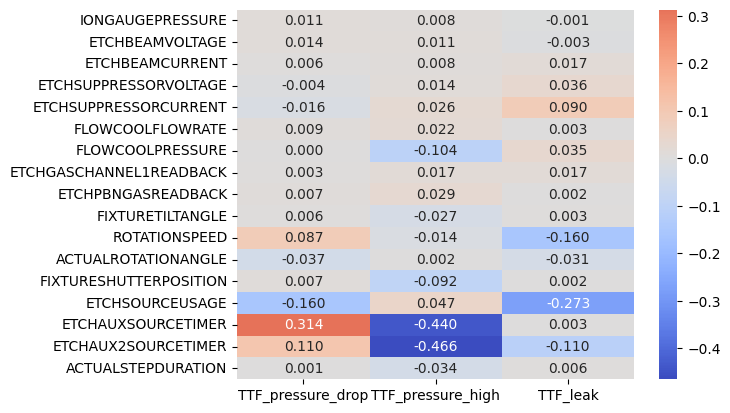

<Figure size 1500x500 with 0 Axes>

In [11]:
# 히트맵으로 상관관계 시각화
import seaborn as sns

sns.heatmap( corr_ttf,
            fmt = '.3f',
            annot = True,
            cmap = 'coolwarm',
            center = 0)

plt.figure(figsize=(15,5))
plt.tight_layout()
plt.show()

                       TTF_pressure_drop  TTF_pressure_high  TTF_leak
IONGAUGEPRESSURE                0.010567           0.008017 -0.001035
ETCHSUPPRESSORCURRENT          -0.015696           0.026035  0.090449
FLOWCOOLPRESSURE                0.000423          -0.103868  0.035274
ACTUALROTATIONANGLE            -0.037254           0.001671 -0.031271
ACTUALSTEPDURATION              0.000578          -0.034361  0.005758


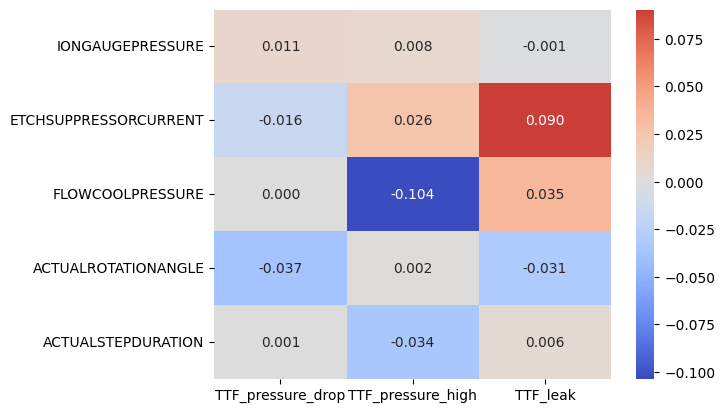

<Figure size 1500x500 with 0 Axes>

In [16]:
# 다섯 개 센서값에 대해서만 상관관계 및 시각화
corr_sensor = df[ sensor_cols + ttf_cols ].corr()
corr_sensor_loc = corr_sensor.loc[sensor_cols, ttf_cols]
print(corr_sensor_loc)

sns.heatmap( corr_sensor_loc,
            fmt = '.3f',
            annot = True,
            cmap = 'coolwarm',
            center=0 )

plt.figure(figsize=(15, 5))
plt.tight_layout()
plt.show()

복습

In [22]:
# 상관관계가 약하므로, 임계값을 정하여 그 구간에서 분포 확인하기

print( df[ ['TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak'] ].describe() )

       TTF_pressure_drop  TTF_pressure_high      TTF_leak
count       3.063960e+06       2.977064e+06  1.375078e+06
mean        4.703427e+06       4.689157e+06  8.145258e+06
std         4.215546e+06       3.367224e+06  4.681798e+06
min         0.000000e+00       0.000000e+00  0.000000e+00
25%         1.174378e+06       1.839644e+06  4.257481e+06
50%         3.235546e+06       4.396413e+06  8.189178e+06
75%         7.401371e+06       6.612137e+06  1.200806e+07
max         1.538524e+07       1.342678e+07  1.689183e+07


In [29]:
# TTF_pressure_high 고장 분석
threshold = 1839644 # 고장에 가까운 하위 25% TTF_pressure_high값 이용

df['label_pressure_high'] = (df['TTF_pressure_high'] <= threshold).astype(int)
print(df['label_pressure_high'].value_counts())

df_normal = df[ df['label_pressure_high'] == 0 ]
df_prefault = df[ df['label_pressure_high'] == 1 ]

print(f"정상 구간 {len(df_normal):,}행")
print(f"고장 임박 {len(df_prefault):,}행")


label_pressure_high
0    2391475
1     744267
Name: count, dtype: int64
정상 구간 2,391,475행
고장 임박 744,267행


In [31]:
print("=== 정상 구간 평균값 ===")
print(df_normal[train_cols].mean())
print(df_prefault[train_cols].mean())

=== 정상 구간 평균값 ===
IONGAUGEPRESSURE          -0.015832
ETCHBEAMVOLTAGE           -0.016416
ETCHBEAMCURRENT           -0.023020
ETCHSUPPRESSORVOLTAGE     -0.026977
ETCHSUPPRESSORCURRENT      0.027016
FLOWCOOLFLOWRATE          -0.032473
FLOWCOOLPRESSURE          -0.083832
ETCHGASCHANNEL1READBACK   -0.025994
ETCHPBNGASREADBACK        -0.022729
FIXTURETILTANGLE           0.013098
ROTATIONSPEED              0.044963
ACTUALROTATIONANGLE        0.015539
FIXTURESHUTTERPOSITION     0.622081
ETCHSOURCEUSAGE           -0.181594
ETCHAUXSOURCETIMER        -0.021931
ETCHAUX2SOURCETIMER       -0.264439
ACTUALSTEPDURATION        -0.048810
dtype: float64
IONGAUGEPRESSURE           0.006362
ETCHBEAMVOLTAGE           -0.055311
ETCHBEAMCURRENT           -0.050934
ETCHSUPPRESSORVOLTAGE     -0.004060
ETCHSUPPRESSORCURRENT     -0.049252
FLOWCOOLFLOWRATE          -0.029731
FLOWCOOLPRESSURE           0.337795
ETCHGASCHANNEL1READBACK   -0.029843
ETCHPBNGASREADBACK        -0.033979
FIXTURETILTANGLE           0.07

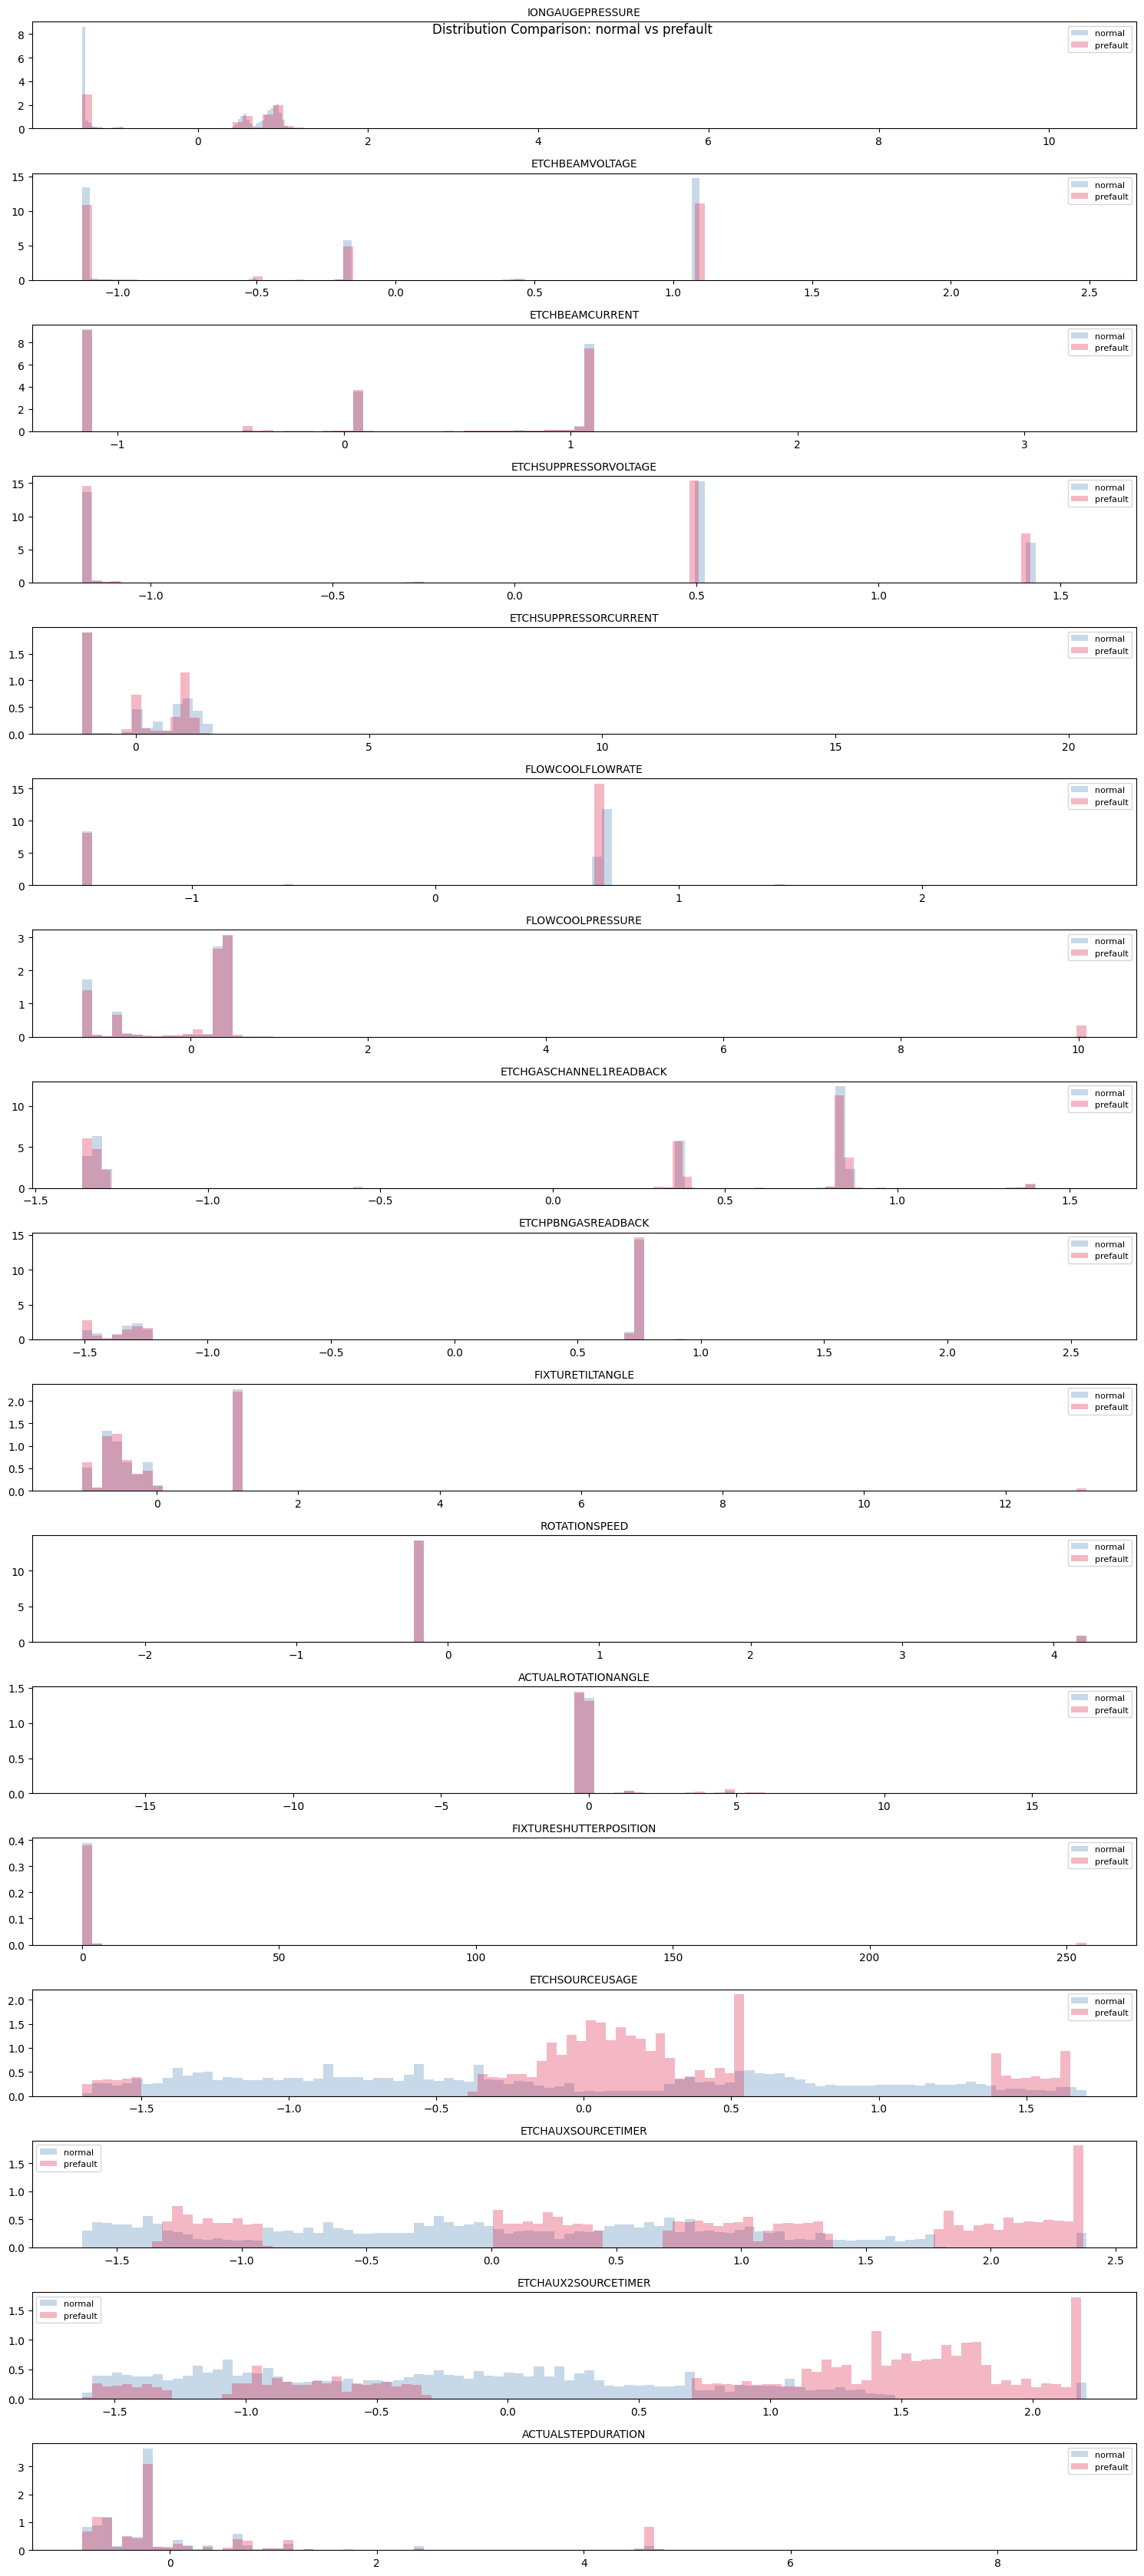

In [35]:
fig, axes = plt.subplots(len(train_cols), 1, figsize=(15, len(train_cols)*2))

for i, col in enumerate(train_cols):
  axes[i].hist( df_normal[col].dropna(), bins=100, alpha=0.3,
               color='steelblue', label='normal', density=True)
  axes[i].hist( df_prefault[col].dropna(), bins=100, alpha=0.3,
               color='crimson', label='prefault', density=True)
  axes[i].set_title(col, fontsize=10)
  axes[i].legend(fontsize=8)

plt.suptitle("Distribution Comparison: normal vs prefault")
plt.tight_layout()
plt.show()

